In [286]:
import numpy as np
import matplotlib.pyplot as plt

In [287]:
seed = 30
rng = np.random.default_rng(seed=seed)

### Part 1

In [288]:
N = 10000
lam = 1
U = rng.uniform(low=0, high=1, size=N)
X_exp = - np.log(U)/lam

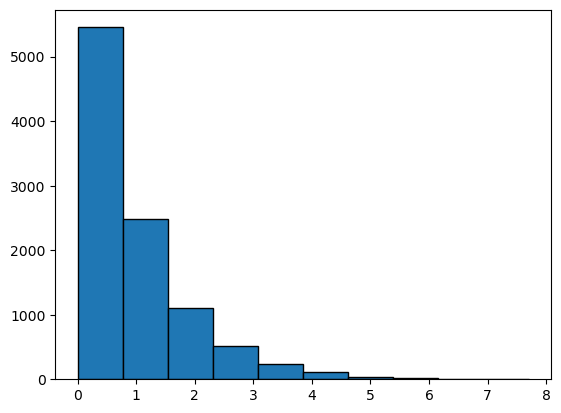

In [289]:
plt.hist(X_exp, edgecolor="black")
plt.show()

In [290]:
U1 = rng.uniform(low=0, high=1, size=int(N/2))
U2 = rng.uniform(low=0, high=1, size=int(N/2))

X_normal = np.concatenate((np.sqrt(-2*np.log(U1)) * np.cos(2*np.pi*U2), np.sqrt(-2*np.log(U1)) * np.sin(2*np.pi*U2)))

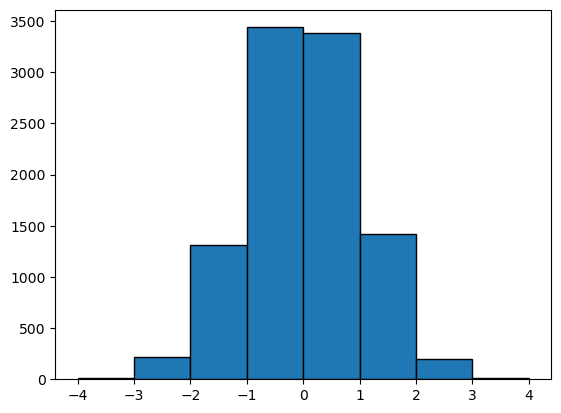

In [291]:
plt.hist(X_normal, bins=[-4,-3,-2,-1,0,1,2,3,4], edgecolor="black")
plt.show()

In [292]:
N = 10000
U = rng.uniform(low=0, high=1, size=N)

beta = 1
k = 2.05

x = np.linspace(1,20,1000)

X_pareto = beta * U**(-1/k)

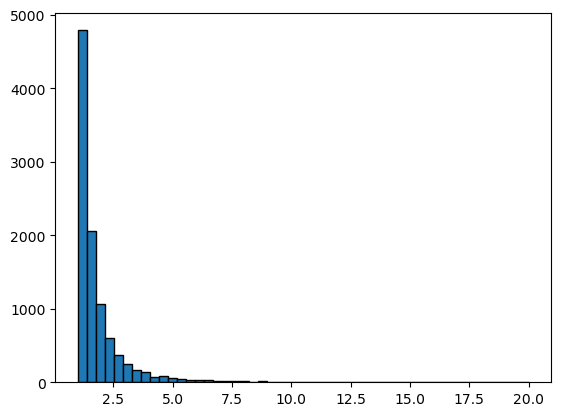

In [293]:
plt.hist(X_pareto, bins=50, range=(1,20), edgecolor='black')
plt.show()

### Part 2

In [294]:
E_true = beta*k/(k-1)
V_true = beta**2 * k/((k-1)**2 * (k-2))
E_sample = np.mean(X_pareto)
V_sample = np.var(X_pareto)
print(E_true, E_sample)
print(V_true, V_sample)

1.9523809523809526 1.9437836605791485
37.18820861678019 5.747221515184065


### Part 4

In [295]:
N = 10_000
lam = 1
U1 = rng.uniform(low=0, high=1, size=N)
U2 = rng.uniform(low=0, high=1, size=N)
Y = - np.log(U1)/lam
X_pareto_comp = - np.log(U2)/Y

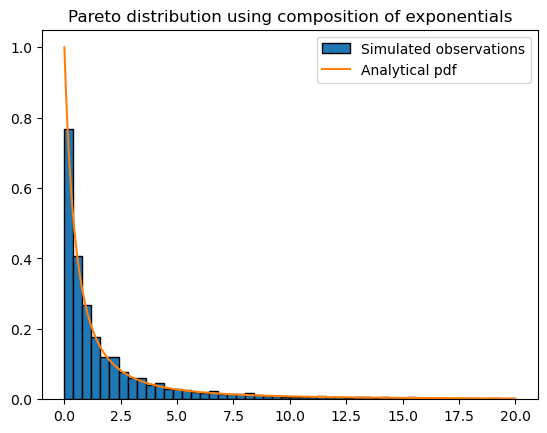

In [296]:
x = np.linspace(0,20,1000)
y = lam/((lam+x)**2)

plt.hist(X_pareto_comp, bins=50, range=(0,20), edgecolor='black', density=True, label='Simulated observations')
plt.plot(x, y, label='Analytical pdf')
plt.legend()
plt.title('Pareto distribution using composition of exponentials')
plt.show()

In [297]:
def est_cdf(x):
    Fx = np.zeros(len(x))
    for i in range(len(x)):
        Fx[i] = np.sum(X_pareto_comp <= x[i])/N
    return Fx

true_cdf = lambda x: 1-1/(1+x/lam)

xs = np.linspace(0,100,1000)
est = est_cdf(xs)
true = true_cdf(xs)              
Dn = np.max(np.abs(est-true))
Dstar = (np.sqrt(N) + 0.12 + 0.11/np.sqrt(N))*Dn
Dstar

1.0256702040160048